In [9]:
import ModelViz
from sklearn.cluster import KMeans
from sklearn import metrics
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from matplotlib.transforms import ScaledTranslation
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn import metrics
import matplotlib.ticker as mticker



Create an instance of the ModelViz class, then use the functions to 
* `load_data / load_mfdata` to load data
* `load_grid` to load grid information
* `summarise_features` to sum sets of variables together
* `preprocess` to strip boundary and normalise 
* `make_tsds` to reshape data into a time series data set (tsds)
* `load_tsds` to load an existing time series data set from csv
* `train` to create a clustering model
* `load_model` to load an existing model
* `predict` to create predictions based on a tsds and model
* `get_cluster_info` to summarise predictions and calcuate mean/std dev for each cluster
* `plot_map` to plot the cluster output as a map
* `plot_ts` to plot time series for each cluster


## Train the model

Create an instace of ModelViz for the training data, read in that data and grid info
Combine variables and preprocess - stripping the boundary layers and normalising
Make the dataset by reshaping the data into the form needed 
Fit the model

In [2]:
def cluster_var_names(classification,norm,vars):
    train = ModelViz.ModelViz()

    # weird formatting of my data....
    train.x_strip = slice(15,-15)
    train.y_strip = slice(15,-15)
    train.n_init = 100 #0
    train.seed = 800
    train.norm = norm
    train.cluster_vars = vars
    train.plot_vars={'N1_p':'Phosph.','N3_n':'Nitrate','O2_o':'Oxyg.','O3_c':'DIC','O3_TA':'Alk.', 'N4_n':'Ammon.', 'N5_s':'Silic.'}
    filename = '/data/proteus1/scratch/rmi/classifications/COMFORT_data/amm7_mean_2000-2004_'+depth+'_'+classification+'.nc'

    train.load_mfdata(filename)

    train.load_grid('/data/sthenno1/to_archive/yuti/yuti-SSB-AMM7-hindcasts/mesh_mask.nc')

    #train.summarise_features(sum_vars)
    train.preprocess(do_slice=False)     
    train.make_tsds()
    train.train(n_clusters=3, save=False,model_name = 'kmeans') #, file_path='model.ks')
    train.predict()
    train.get_cluster_info(save=False)
    return train


In [3]:
classification = 'biogeo'
depth = 'surface'

train1 = cluster_var_names(classification,True,['N1_p'])

Processing N1_p


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 66.25it/s]


In [4]:
classification = 'biogeo'
depth = 'surface'

train2 = cluster_var_names(classification,True,['N3_n'])

Processing N3_n


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 64.86it/s]


In [5]:
classification = 'biogeo'
depth = 'surface'

train3 = cluster_var_names(classification,True,['N1_p','N3_n'])

Processing N1_p


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 65.58it/s]


Processing N3_n


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 67.43it/s]


In [23]:
print(len(train2.labels[train2.labels==0]))
print(len(train2.labels[train2.labels==1]))
print(len(train2.labels[train2.labels==2]))

57069
865
70


In [43]:
# switch labels so the same clusters have the same colours - label ordering is random
train3.cluster_ds['class_map_old'] = train3.cluster_ds.class_map
train3.cluster_ds['class_map'] = xr.where(train3.cluster_ds.class_map_old == 1,2,train3.cluster_ds.class_map)
train3.cluster_ds['class_map'] = xr.where(train3.cluster_ds.class_map_old == 2,1,train3.cluster_ds.class_map)

In [41]:
print(metrics.rand_score(train1.labels,train3.labels))

print(metrics.rand_score(train2.labels,train3.labels))


0.6326526555975016
0.8427382378604548


Plot data

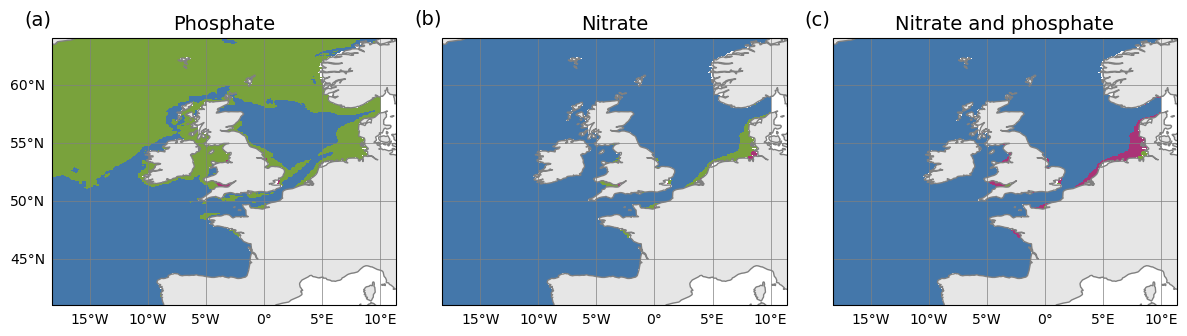

In [12]:


vibrant = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988']
bright = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377']

def plot_map(ax,train,hex_list,title_val,label,left_ticks):
    train.cmap = train.make_cmap(hex_list)
    ax.pcolormesh(train.cluster_ds.lon, train.cluster_ds.lat, train.cluster_ds.class_map, cmap=train.cmap)
    ax.add_feature(NaturalEarthFeature(category="physical", facecolor=[0.9, 0.9, 0.9], name="coastline", scale="50m"),
                   edgecolor="gray")
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color="gray", linestyle="-")
    gl.top_labels = False
    gl.bottom_labels = True
    gl.right_labels = False
    gl.left_labels = left_ticks
    gl.ylocator = mticker.FixedLocator([45,50,55,60])
    ax.set_aspect("equal")
    ax.set_title(title_val,fontsize=14)
    ax.text(
    0.0, 1.0, label, transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
    fontsize=14, va='bottom')

fig = plt.figure(layout="constrained",figsize=[12,5])

gs = GridSpec(3, 6, figure=fig)
ax1 = fig.add_subplot(gs[0:-1, 0:2], projection = ccrs.PlateCarree())
plot_map(ax1,train1,bright,'Phosphate','(a)',True)
ax2 = fig.add_subplot(gs[0:-1, 2:4], projection = ccrs.PlateCarree())
plot_map(ax2,train2,bright,'Nitrate','(b)',False)
ax3 = fig.add_subplot(gs[0:-1, 4:], projection = ccrs.PlateCarree())
plot_map(ax3,train3,bright,'Nitrate and phosphate','(c)',False)


plt.tight_layout()
plt.savefig('standardisation.png')

In [7]:
classification = 'biogeo'
depth = 'surface'

train1 = cluster_var_names(classification,None,['N1_p','N3_n','N4_n','N5_s','O2_o','O3_c','O3_TA'])

Processing N1_p


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 84.68it/s]


Processing N3_n


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 91.00it/s]


Processing N4_n


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 87.92it/s]


Processing O3_c


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 87.99it/s]


Processing O3_TA


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 88.59it/s]


In [8]:
classification = 'biogeo'
depth = 'surface'

train2 = cluster_var_names(classification,True,['N1_p','N3_n','N4_n','N5_s','O2_o','O3_c','O3_TA'])

Processing N1_p


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 68.93it/s]


Processing N3_n


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 68.87it/s]


Processing N4_n


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 69.64it/s]


Processing O3_c


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 68.96it/s]


Processing O3_TA


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 69.06it/s]


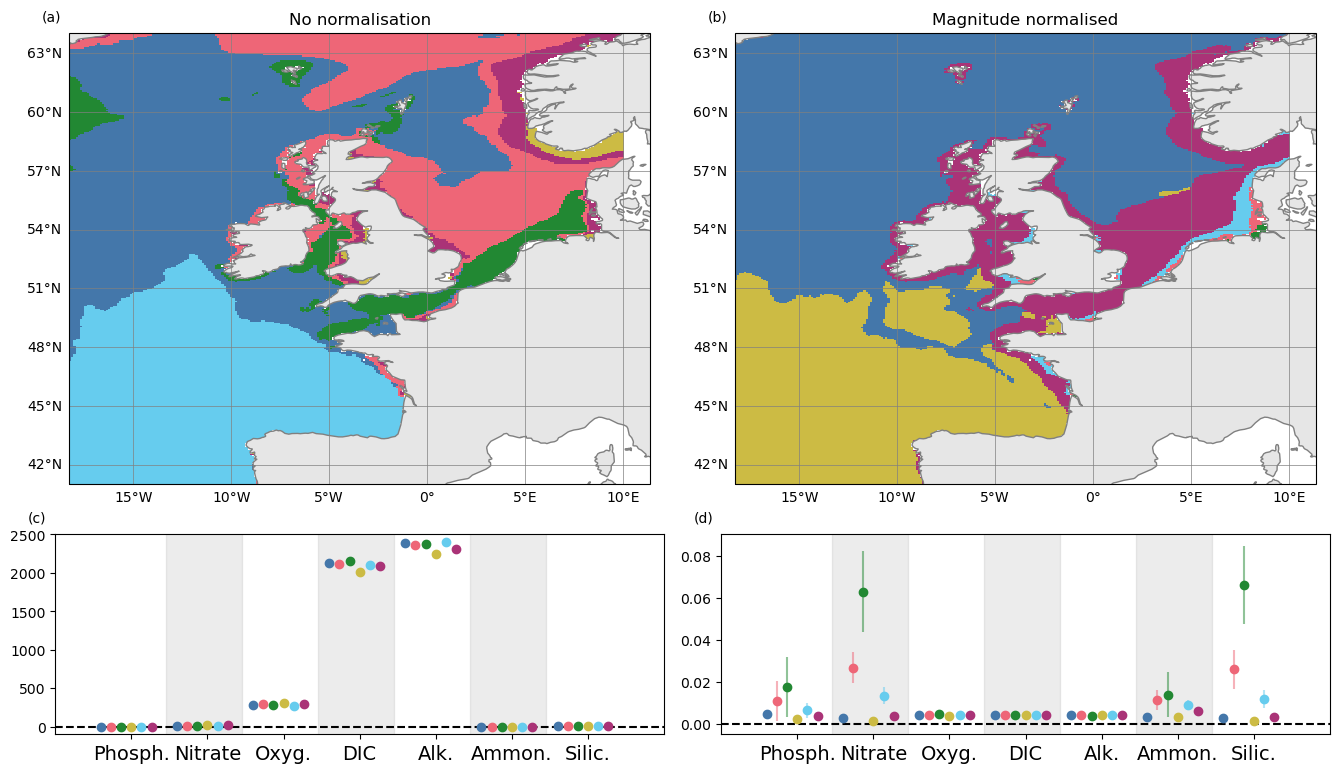

In [31]:
vibrant = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988']
bright = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377']

def plot_map(ax,train,hex_list,title_val,label):
    train.cmap = train.make_cmap(hex_list)
    ax.pcolormesh(train.cluster_ds.lon, train.cluster_ds.lat, train.cluster_ds.class_map, cmap=train.cmap)
    ax.add_feature(NaturalEarthFeature(category="physical", facecolor=[0.9, 0.9, 0.9], name="coastline", scale="50m"),
                   edgecolor="gray")
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color="gray", linestyle="-")
    gl.top_labels = False
    gl.bottom_labels = True
    gl.right_labels = False
    gl.left_labels = True
    ax.set_aspect("equal")
    ax.set_title(title_val)
    ax.text(
    0.0, 1.0, label, transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
    fontsize='medium', va='bottom')

def plot_vars(ax,train,hex_list,y_label,label,min_val,max_val):
    train.cmap_discrete = hex_list
    ax.hlines(0,0,len(train.plot_vars)+2,linestyle='--',color='black')
    ax.fill_between([1.45,2.45], -0.01, 2500, 
                color='grey', alpha=0.15, transform=ax.get_xaxis_transform())
    ax.fill_between([3.45,4.45], -0.01, 2500, 
                color='grey', alpha=0.15, transform=ax.get_xaxis_transform())
    ax.fill_between([5.45,6.45], -0.01, 2500, 
                color='grey', alpha=0.15, transform=ax.get_xaxis_transform())
    for i in range(train.model.n_clusters):
        x_tick_labels = np.asarray([])
        increment = 0.8*(i-train.model.n_clusters/2)/train.model.n_clusters
        for v,var in enumerate(train.plot_vars):
            xbar = train.cluster_ds.class_TS.sel(var=var,vclass=i)
            xstd = train.cluster_ds.class_TS_std.sel(var=var,vclass=i)
            ax.plot(v+1+increment,xbar,'o',label=train.plot_vars[var],c=train.cmap_discrete[i])
            ax.errorbar(v+1+increment,xbar,xstd,alpha=0.5,color=train.cmap_discrete[i])
            x_tick_labels = np.append(x_tick_labels,[train.plot_vars[var]])
        ax.set_xlim([0,v+2])
        ax.set_xticks(range(1,v+2),x_tick_labels,fontsize=14)
    ax.set_ylabel(y_label)
    ax.set_ylim((min_val,max_val))
    ax.text(
    0.0, 1.0, label, transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
    fontsize='medium', va='bottom')
    
fig = plt.figure(layout="constrained",figsize=[13.5,7.75])

gs = GridSpec(3, 2, figure=fig)
ax1 = fig.add_subplot(gs[0:2, 0], projection = ccrs.PlateCarree())
plot_map(ax1,train1,bright,'No normalisation','(a)')
ax2 = fig.add_subplot(gs[0:2, 1], projection = ccrs.PlateCarree())
plot_map(ax2,train2,bright,'Magnitude normalised','(b)')
ax3 = fig.add_subplot(gs[2, 0])
plot_vars(ax3,train1,bright,'','(c)',-100,2500)
ax4 = fig.add_subplot(gs[2, 1])
plot_vars(ax4,train2,bright,'','(d)',-0.005,0.09)

#plt.show()


patch1 = mpatches.Patch(color=bright[3], label='North')
patch2 = mpatches.Patch(color=bright[0], label='South')
patch3 = mpatches.Patch(color=bright[1], label='Shelf')
patch4 = mpatches.Patch(color=bright[4], label='German bight')
patch5 = mpatches.Patch(color=bright[5], label='Coastal 1')
patch6 = mpatches.Patch(color=bright[2], label='Coastal 2')




#ax5.legend(handles=[patch1, patch2,patch3,patch4,patch5,patch6],bbox_to_anchor=(1,0.5),loc='center right',facecolor='white', framealpha=1,fontsize=13)
#ax5.axis('off')

plt.tight_layout()
#plt.savefig('figure S1.png')